<a href="https://colab.research.google.com/github/lakshmiramki2008-dotcom/codealpha_tasks-/blob/main/codealpha_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Unemployment in India (1).csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
# Get information about the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


None

In [ ]:
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Drop rows with any missing values
df.dropna(inplace=True)

# Display the cleaned DataFrame information and head to verify changes
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


None

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
# Extract Month, Year, and Quarter for further analysis
df['Month'] = df['Date'].dt.month
df['Month_int'] = df['Month'].apply(lambda x: int(x))
df['Month_name'] = df['Date'].dt.strftime('%b')
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter

# Display the first few rows with the new features
display(df.head())

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Month_int,Month_name,Year,Quarter
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5,5,May,2019,2
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6,6,Jun,2019,2
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7,7,Jul,2019,3
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8,8,Aug,2019,3
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9,9,Sep,2019,3


,Estimated Unemployment Rate (%)
count,740.000000
mean,11.787946
std,10.721298
min,0.000000
25%,4.657500
50%,8.350000
75%,15.887500
max,76.740000


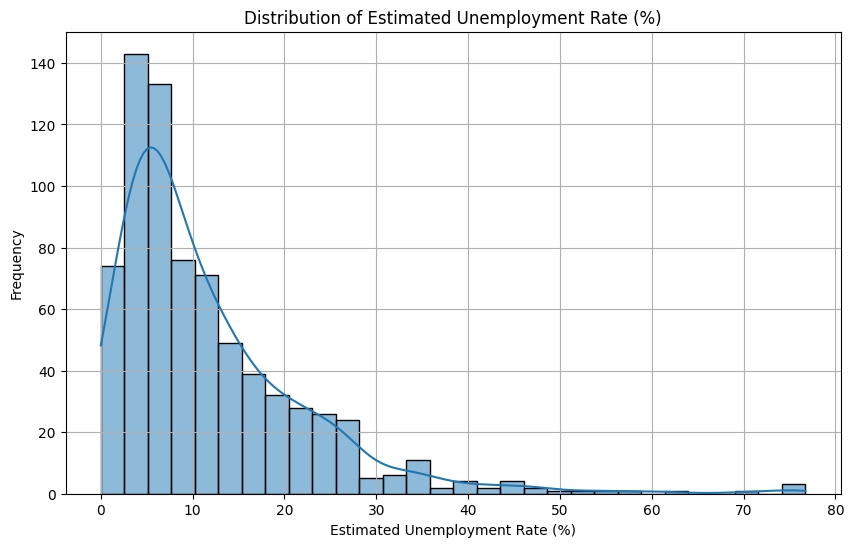

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive statistics for 'Estimated Unemployment Rate (%)'
display(df['Estimated Unemployment Rate (%)'].describe())

# Visualize the distribution of unemployment rates
plt.figure(figsize=(10, 6))
sns.histplot(df['Estimated Unemployment Rate (%)'], bins=30, kde=True)
plt.title('Distribution of Estimated Unemployment Rate (%)')
plt.xlabel('Estimated Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

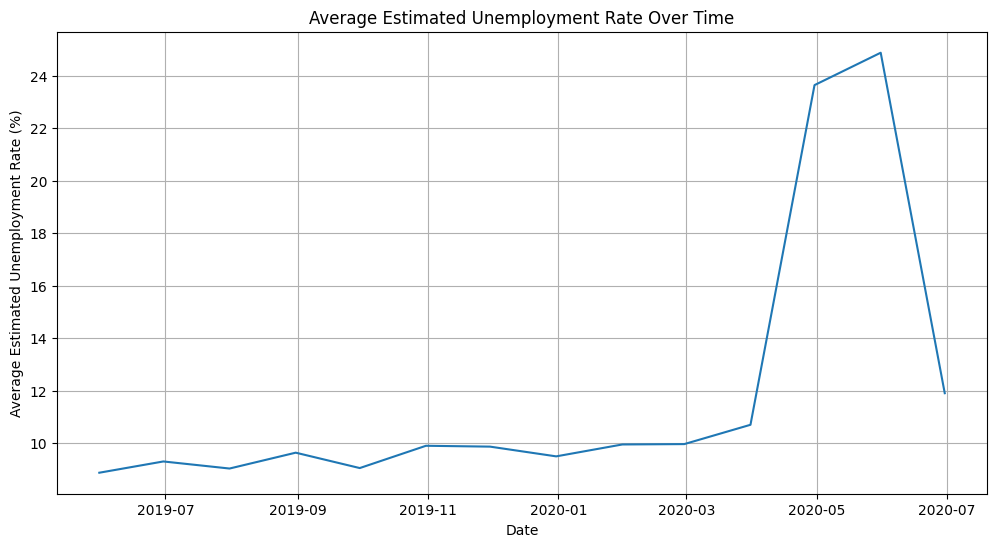

In [ ]:
# Group by Date and calculate the mean unemployment rate
unemployment_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

# Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=unemployment_trend)
plt.title('Average Estimated Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.grid(True)
plt.show()

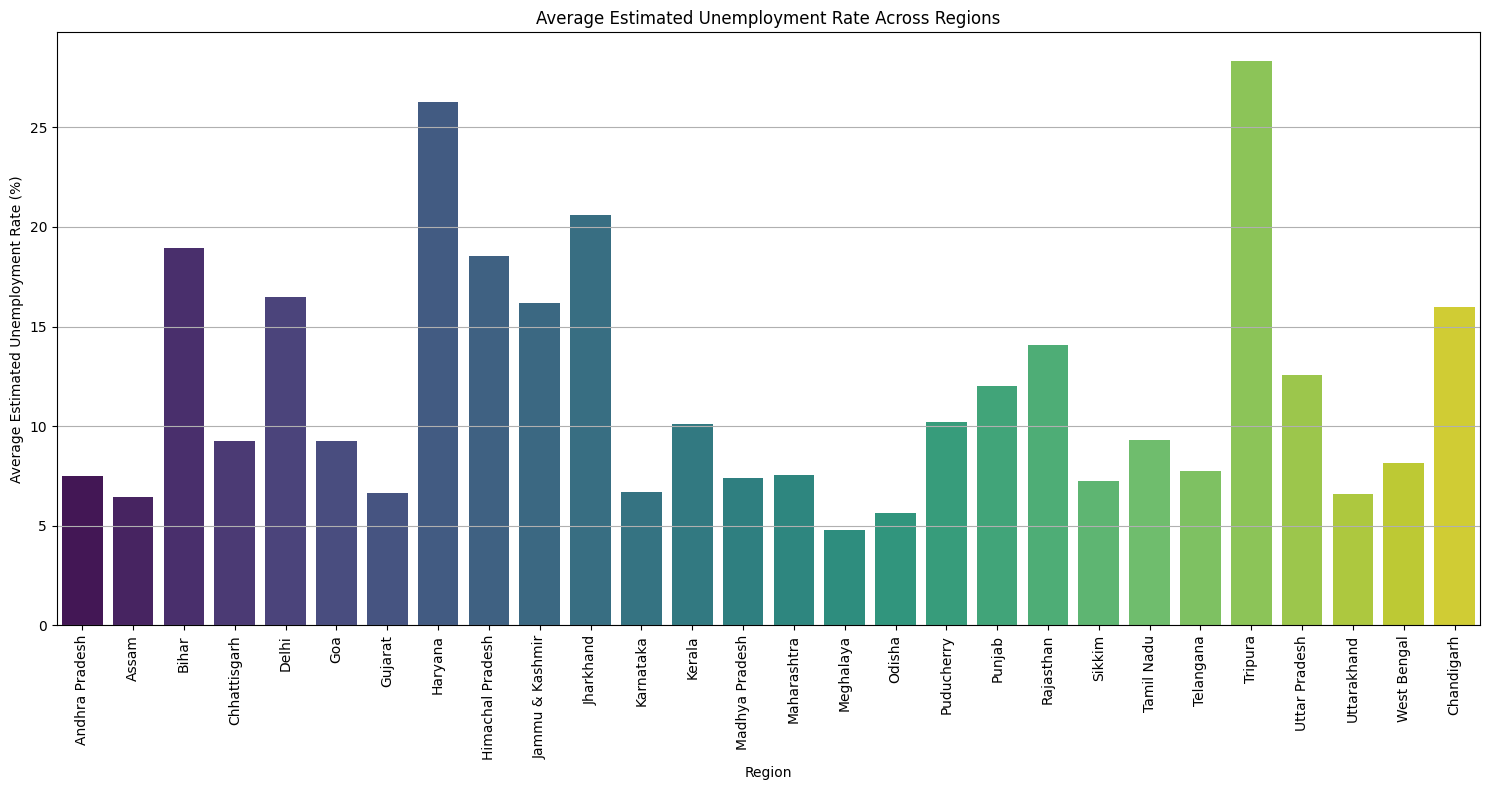

In [ ]:
# Visualize unemployment rate across different regions
plt.figure(figsize=(15, 8))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df, errorbar=None, palette='viridis', hue='Region', legend=False)
plt.title('Average Estimated Unemployment Rate Across Regions')
plt.xlabel('Region')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

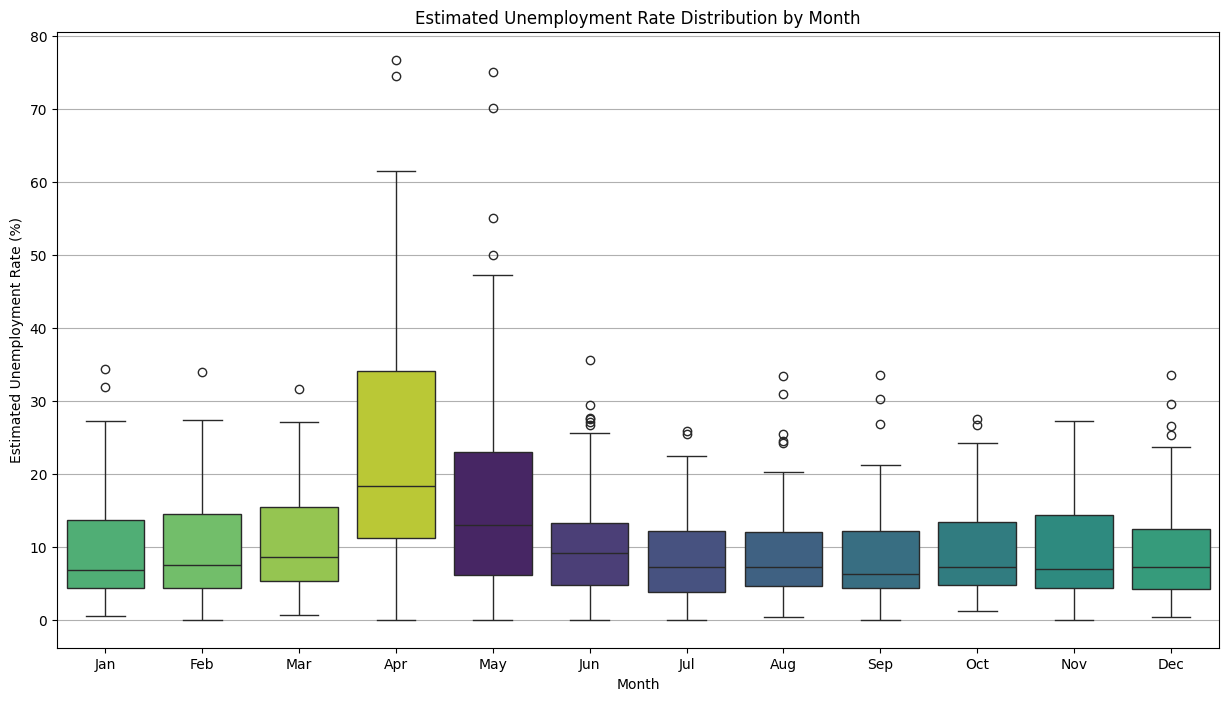

In [ ]:
# Box plot to visualize unemployment rate by month
plt.figure(figsize=(15, 8))
sns.boxplot(x='Month_name', y='Estimated Unemployment Rate (%)', data=df, palette='viridis', order=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
], hue='Month_name', legend=False)
plt.title('Estimated Unemployment Rate Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(axis='y')
plt.show()

In [ ]:
# Define the Covid-19 impact period (e.g., from March 2020 onwards)
covid_start_date = pd.to_datetime('2020-03-01')
df['Covid_Impact'] = df['Date'] >= covid_start_date

# Display the count of records before and during Covid-19 impact
display(df['Covid_Impact'].value_counts())

# Calculate average unemployment rate before and during Covid-19
unemployment_before_covid = df[~df['Covid_Impact']]['Estimated Unemployment Rate (%)'].mean()
unemployment_during_covid = df[df['Covid_Impact']]['Estimated Unemployment Rate (%)'].mean()

print(f"Average Unemployment Rate (Before Covid-19): {unemployment_before_covid:.2f}%")
print(f"Average Unemployment Rate (During Covid-19): {unemployment_during_covid:.2f}%")

,count
Covid_Impact,
False,536
True,204


Average Unemployment Rate (Before Covid-19): 9.51%
Average Unemployment Rate (During Covid-19): 17.77%


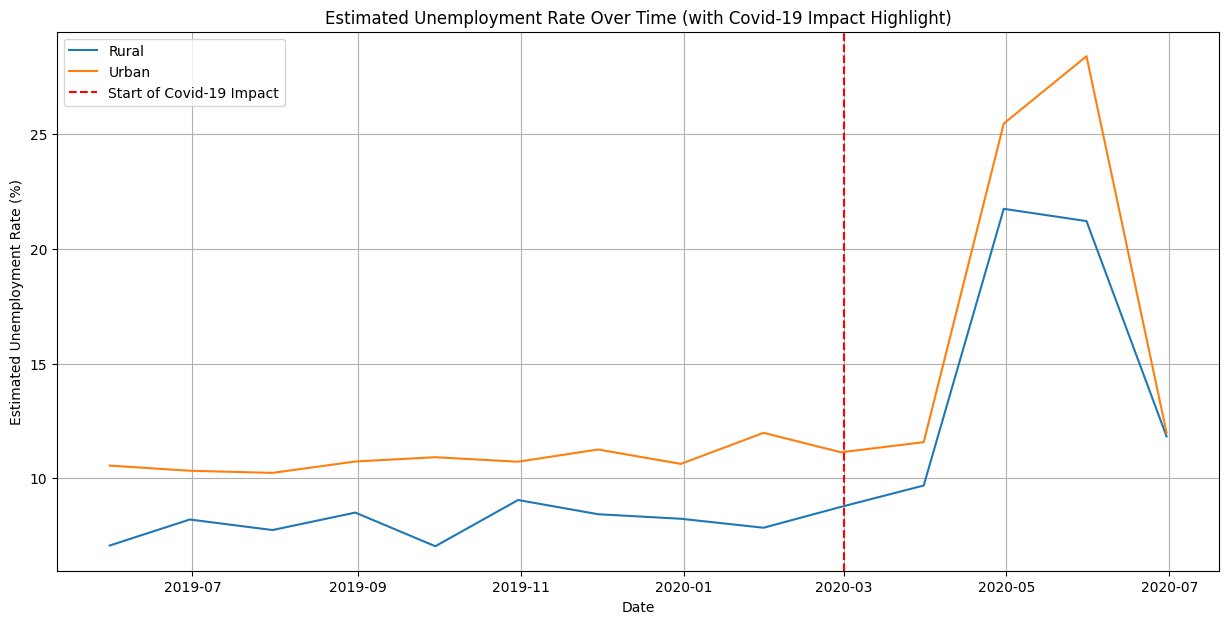

In [ ]:
# Visualize unemployment rate over time, highlighting the Covid-19 period
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df, hue='Area', errorbar=None)
plt.axvline(x=covid_start_date, color='red', linestyle='--', label='Start of Covid-19 Impact')
plt.title('Estimated Unemployment Rate Over Time (with Covid-19 Impact Highlight)')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.legend()
plt.grid(True)
plt.show()